# Chapter5_Applied_Aknes


In [13]:
import Utils_Surface_NS as us
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Utils_Surface_NS as us
import importlib



import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, auc, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from scipy.stats import chi2
import scipy.stats
from sklearn.linear_model import LogisticRegression


import keras
from keras.layers import Dense, Flatten, Input, Concatenate,Conv1D, Conv2D, Dropout, MaxPooling2D, MaxPooling1D
from keras.models import Model, Sequential
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf
from sklearn.metrics import mean_squared_error

from scipy.stats import percentileofscore

In [14]:
df_metro = pd.read_csv('Surface_Events_covariates.csv', index_col=0, parse_dates=True)
full_range = pd.date_range(start=df_metro.index.min(), end=df_metro.index.max(), freq='D')
missing_days = full_range.difference(df_metro.index)
df_metro = df_metro.reindex(full_range)

df_metro = df_metro.ffill().bfill()

df_metro["snow_S"] = (df_metro["snow_S"] - df_metro["snow_S"].max()) / (df_metro["snow_S"].max() - df_metro["snow_S"].min())
df_metro['wp'] = df_metro['wp'].rolling(window=2, min_periods=1).mean()
df_metro['wp'] = (df_metro['wp'] - df_metro['wp'].min()) / (df_metro['wp'].max() - df_metro['wp'].min())
df_metro['N_geophones'] = (df_metro['N_geophones'] - df_metro['N_geophones'].min()) / (df_metro['N_geophones'].max() - df_metro['N_geophones'].min())

temp = df_metro['temperature'] = df_metro['temperature'].rolling(window=4, min_periods=1).mean()
scale = max(temp.max(), -temp.min())  # symmetric scaling
df_metro['temperature'] = temp / scale
df_metro.head()

catalogue_path = "Surface_Catalogues"
df_events = us.read_cataloge(catalogue_path)
df_events.sort_index(inplace=True) #Sortere etter tidspunktet for observasjon i tilfelle det ble feil under nedlastning
df_events.index = df_events.index.tz_localize(None)

df_events = df_events.loc[df_events["Type"] == "Slope_HF"]

timestamps = df_events.index
timestamps = timestamps[(timestamps < df_metro.index.max()) & (timestamps > df_metro.index.min())]
print("Date range:", np.min(df_events.index), "  to  ", np.max(df_events.index))
year_dict = {}


col_names_params = [
    r"$\beta_0$",
    r"$\beta_1$",
    r"$\beta_2$",
    r"$\beta_3$",
    r"$\beta_4$",
    r"$\beta_5$",
    r"$\beta_6$"
]

Surface_Catalogues/catalog_2024.csv
Surface_Catalogues/catalog_2018.csv
Surface_Catalogues/catalog_2019.csv
Surface_Catalogues/catalog_2022.csv
Surface_Catalogues/catalog_2023.csv
Surface_Catalogues/catalog_2009.csv
Surface_Catalogues/catalog_2021.csv
Surface_Catalogues/catalog_2020.csv
Surface_Catalogues/catalog_2008.csv
Surface_Catalogues/catalog_2011.csv
Surface_Catalogues/catalog_2010.csv
Surface_Catalogues/catalog_2012.csv
Surface_Catalogues/catalog_2013.csv
Surface_Catalogues/catalog_2007.csv
Surface_Catalogues/catalog_2017.csv
Surface_Catalogues/catalog_2016.csv
Surface_Catalogues/catalog_2014.csv
Surface_Catalogues/catalog_2015.csv
Date range: 2007-01-02 17:07:12   to   2024-06-02 07:05:42


In [15]:
df_metro.describe()

,rain,temperature,snow_S,wp,N_geophones,doy_sin,doy_cos,doy
count,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3.608000e+03,3608.000000,3608.000000
mean,4.967461,0.021648,-0.893811,0.468245,0.698760,-1.609833e-03,0.012343,183.124723
std,10.091633,0.323843,0.199302,0.308180,0.211176,7.108890e-01,0.703391,106.058115
min,0.000000,-0.847938,-1.000000,0.000000,0.000000,-9.999907e-01,-0.999963,1.000000
25%,0.000000,-0.234536,-1.000000,0.131707,0.500000,-7.116566e-01,-0.683919,91.000000
50%,0.700000,-0.019330,-1.000000,0.563110,0.625000,6.432491e-16,0.021516,184.000000
75%,5.200000,0.279961,-0.871795,0.725381,0.875000,7.116566e-01,0.714673,275.250000
max,121.900000,1.000000,0.000000,1.000000,1.000000,9.999907e-01,1.000000,366.000000


# NHPP

In [17]:
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

# --- Step 1: pick covariates for PCA
covariates = [ "wp", "temperature"]  # example
X = df_metro[covariates].values

df_design = pd.DataFrame({
    "time": df_metro.index,               # assumes DateTimeIndex
    "temperature": df_metro.temperature,
    "wp": df_metro.wp,
    "N_geophones": df_metro["N_geophones"]
})

years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

df_design.insert(0, "intercept", 1.0)  # add column of ones
df_design = df_design[df_design.index.year.isin(years)]
# observed events: array of event times
event_times = timestamps[timestamps.year.isin(years)]
event_times = timestamps.to_numpy()

# --- Step 4: intensity function
def intensity(params, X):
    return np.exp(np.dot(X, params))
# --- Step 5: log-likelihood

def neg_loglik(params, df_design, event_times):

    X = df_design.drop(columns="time").values
    lam_t = intensity(params, X)

    # integral term using rectangle rule
    t_sec = df_design["time"].astype("int64") / 1e9 / 86400
    dt = np.diff(t_sec)
    lam_integral = np.sum(lam_t[:-1] * dt)

    # event term: interpolate lambda at observed event times
    event_sec = event_times.astype("int64")/1e9/ 86400
    lam_events = np.interp(event_sec, t_sec, lam_t)

    return -(np.sum(np.log(lam_events)) - lam_integral)

# --- Optimization example
params_init = np.zeros(df_design.shape[1]-1)  # minus 1 for 'time' column

res = minimize(neg_loglik, x0=params_init, args=(df_design, event_times))

param_names = df_design.drop(columns="time").columns

for name, est in zip(param_names, res.x):
    print(f"{name:15s} = {est:.3f}")


intercept       = 0.121
temperature     = -0.818
wp              = -0.522
N_geophones     = 1.503


In [18]:
import numdifftools as nd
from scipy.stats import norm

# Hessian and standard errors
hess = nd.Hessian(lambda p: neg_loglik(p, df_design, event_times))(res.x)
cov = np.linalg.inv(hess)
se = np.sqrt(np.diag(cov))

# 90% CI
z = norm.ppf(0.90)
cis = np.vstack([res.x - z*se, res.x + z*se]).T

for name, est, ci in zip(param_names, res.x, cis):
    print(f"{name:15s} = {est:.3f} (90% CI: {ci[0]:.3f}, {ci[1]:.3f})")

intercept       = 0.121 (90% CI: 0.055, 0.186)
temperature     = -0.818 (90% CI: -0.877, -0.760)
wp              = -0.522 (90% CI: -0.578, -0.466)
N_geophones     = 1.503 (90% CI: 1.433, 1.573)


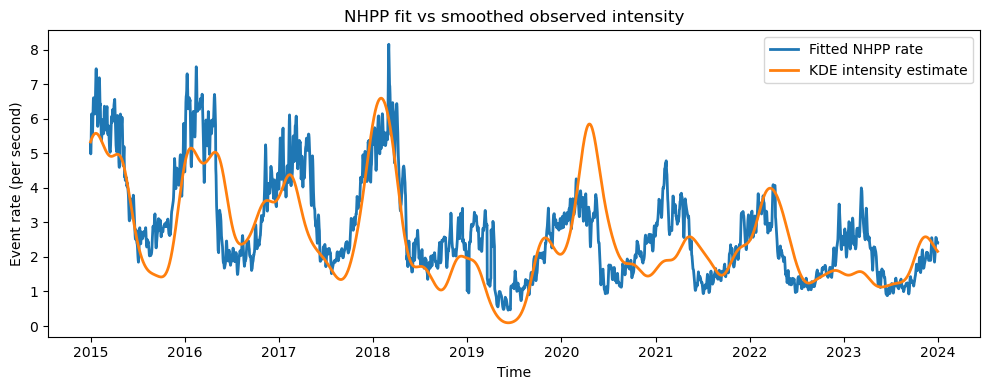

In [40]:
from scipy.stats import gaussian_kde

# --- Fitted rate from NHPP (generalized)
t_grid = df_design["time"]
X = df_design.drop(columns="time").values  # all covariates
lam_fit = intensity(res.x, X)

# --- KDE-based intensity estimate
event_sec = event_times.astype("int64")/1e9/ 86400
t_sec = t_grid.astype("int64")/1e9/ 86400

kde = gaussian_kde(event_sec, bw_method=0.03)
kde_vals = kde(t_sec) * len(event_sec)  # scale to event rate

# --- Plot
plt.figure(figsize=(10,4))
plt.plot(t_grid, lam_fit, label="Fitted NHPP rate", lw=2)
plt.plot(t_grid, kde_vals, label="KDE intensity estimate", lw=2)
plt.xlabel("Time")
plt.ylabel("Event rate (per second)")
plt.title("NHPP fit vs smoothed observed intensity")
plt.legend()
plt.tight_layout()
plt.show()

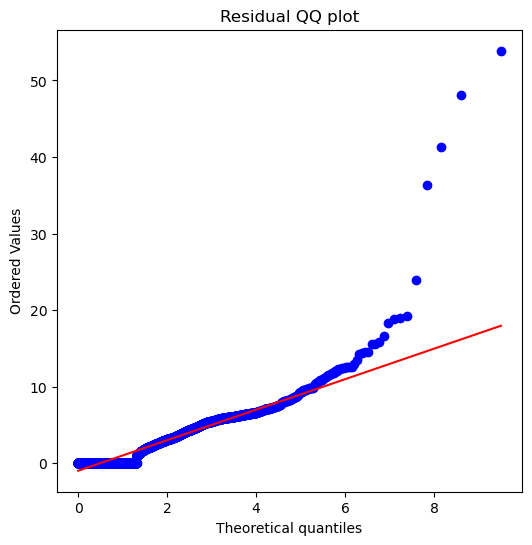

In [41]:
from scipy.interpolate import interp1d

# --- Compute cumulative intensity (numerical integration)
t_sec = df_design["time"].astype("int64")/1e9/ 86400
X = df_design.drop(columns="time").values
lam_t = intensity(res.x, X)

# interpolate lambda for continuous integration
lam_interp = interp1d(t_sec, lam_t, kind="linear", fill_value="extrapolate")

# integrate lambda up to each event time
tau = []
for t_ev in event_times.astype("int64")/1e9/ 86400:
    # simple trapezoid approximation from start to event time
    idx = np.searchsorted(t_sec, t_ev)
    integral = np.trapz(lam_t[:idx], t_sec[:idx])
    tau.append(integral)
tau = np.array(tau)

# --- Inter-event times (should be ~Exp(1))
residuals = np.diff(np.insert(tau, 0, 0))

# --- Plot QQ against exponential
import scipy.stats as stats
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist=stats.expon, plot=plt)
plt.title("Residual QQ plot")
plt.show()

# Neyman-Scott

In [43]:
importlib.reload(us)

col_names_params_NS = [
    r"$\log(\delta)$",
    r"$\log(\sigma^2)$",
    r"$\beta_0$",
    r"$\beta_1$",
    r"$\beta_2$",
    r"$\beta_3$",
    r"$\beta_4$",
    r"$\beta_5$",
    r"$\beta_6$"
]

J_train = 10000
J_test = 100
K = 3
error = 0

#log(delta), log(sigma^2), beta_0, beta_1, beta_2, beta_3, beta_4, beta_5, beta_6
l_bounds_NS = np.array([np.log(0.01), np.log(0.001), -3, -2, -2, -1])
u_bounds_NS = np.array([np.log(10),  np.log(1),  2,  1, 1, 3])

p = len(l_bounds_NS)
years = df_metro.index.year.unique().values[1:-1]
#years = years[years!=2019]
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
T = len(years)*365

params_sample_train_NS = us.LHS(J_train, l_bounds_NS, u_bounds_NS, years)
params_sample_test_NS = us.LHS(J_test, l_bounds_NS, u_bounds_NS, years)

X_train, Y_train, metro_year_list_train, invalid_index_train = us.simulate_given_params(J=J_train, K=K, T=T, p=p, df_metro = df_metro, params=params_sample_train_NS, error = error)
X_test, Y_test, metro_year_list_test, invalid_index_test = us.simulate_given_params(J=J_test, K=K, T=T, p=p, df_metro = df_metro, params=params_sample_test_NS, error = error)

print("Max number of events in a year = ", np.max([x.shape[0] for x in X_train]))
print("Min number of events in a year = ", np.min([x.shape[0] for x in X_train]))
print("Data shape = ", len(X_train))

0 / 10
1 / 10
2 / 10
3 / 10
4 / 10
5 / 10
6 / 10
7 / 10
8 / 10
9 / 10
0 / 100
1 / 100
2 / 100
3 / 100
4 / 100
5 / 100
6 / 100
7 / 100
8 / 100
9 / 100
10 / 100
11 / 100
12 / 100
13 / 100
14 / 100
15 / 100
16 / 100
17 / 100
18 / 100
19 / 100
20 / 100
21 / 100
22 / 100
23 / 100
24 / 100
25 / 100
26 / 100
27 / 100
28 / 100
29 / 100
30 / 100
31 / 100
32 / 100
33 / 100
34 / 100
35 / 100
36 / 100
37 / 100
38 / 100
39 / 100
40 / 100
41 / 100
42 / 100
43 / 100
44 / 100
45 / 100
46 / 100
47 / 100
48 / 100
49 / 100
50 / 100
51 / 100
52 / 100
53 / 100
54 / 100
55 / 100
56 / 100
57 / 100
58 / 100
59 / 100
60 / 100
61 / 100
62 / 100
63 / 100
64 / 100
65 / 100
66 / 100
67 / 100
68 / 100
69 / 100
70 / 100
71 / 100
72 / 100
73 / 100
74 / 100
75 / 100
76 / 100
77 / 100
78 / 100
79 / 100
80 / 100
81 / 100
82 / 100
83 / 100
84 / 100
85 / 100
86 / 100
87 / 100
88 / 100
89 / 100
90 / 100
91 / 100
92 / 100
93 / 100
94 / 100
95 / 100
96 / 100
97 / 100
98 / 100
99 / 100
Max number of events in a year =  25944


In [44]:
importlib.reload(us)

percentiles = [20, 50, 90]
cluster_bins = [0.01, 0.1, 1., 10]

gs = len(l_bounds_NS) + len(cluster_bins) + len(percentiles) - 1 
SS_0_train = np.zeros((len(X_train), gs))
SS_0_test = np.zeros((len(X_test), gs))


for i,x in enumerate(X_train):
    SS_0_train[i,:] = us.summary_statistics(x, T, cluster_bins, percentiles, df_metro, metro_year_list_train[i], verbose=False, p = p)
    print(i)

for i,x in enumerate(X_test):
    SS_0_test[i,:] = us.summary_statistics(x, T, cluster_bins, percentiles, df_metro, metro_year_list_test[i], verbose=False, p = p)
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
25

# Summary stats diagnostics

In [45]:

mask = timestamps.year.isin(years)
X_observed = timestamps[mask]
t0 = X_observed.min()
X_observed = (X_observed - t0).total_seconds() / 86400.0
X_observed = X_observed.to_numpy()
SS_observed = us.summary_statistics(X_observed, T, cluster_bins, percentiles, df_metro, years, verbose=False, p = p)


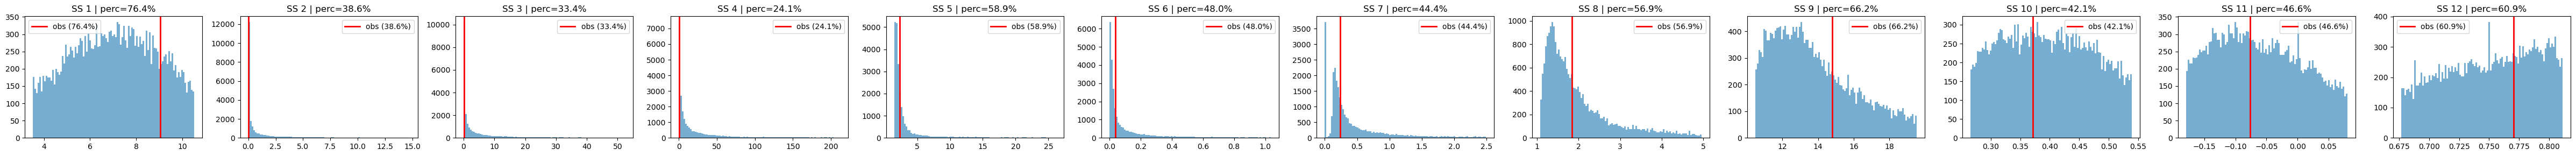

In [11]:
fig, axes = plt.subplots(1, SS_0_train.shape[1], figsize=(4*SS_0_train.shape[1], 3))

for i in range(SS_0_train.shape[1]):
    ax = axes[i] if SS_0_train.shape[1] > 1 else axes

    # percentile of observed wrt training distribution
    perc = percentileofscore(SS_0_train[:, i], SS_observed[i])

    # compute 5th and 95th percentile for histogram range
    lower, upper = np.percentile(SS_0_train[:, i], [10, 90])

    ax.hist(SS_0_train[:, i], bins=100, range=(lower, upper), alpha=0.6)
    ax.axvline(SS_observed[i], color="red", lw=2, label=f"obs ({perc:.1f}%)")
    ax.set_title(f"SS {i+1} | perc={perc:.1f}%")
    ax.legend()

plt.tight_layout()
plt.show()


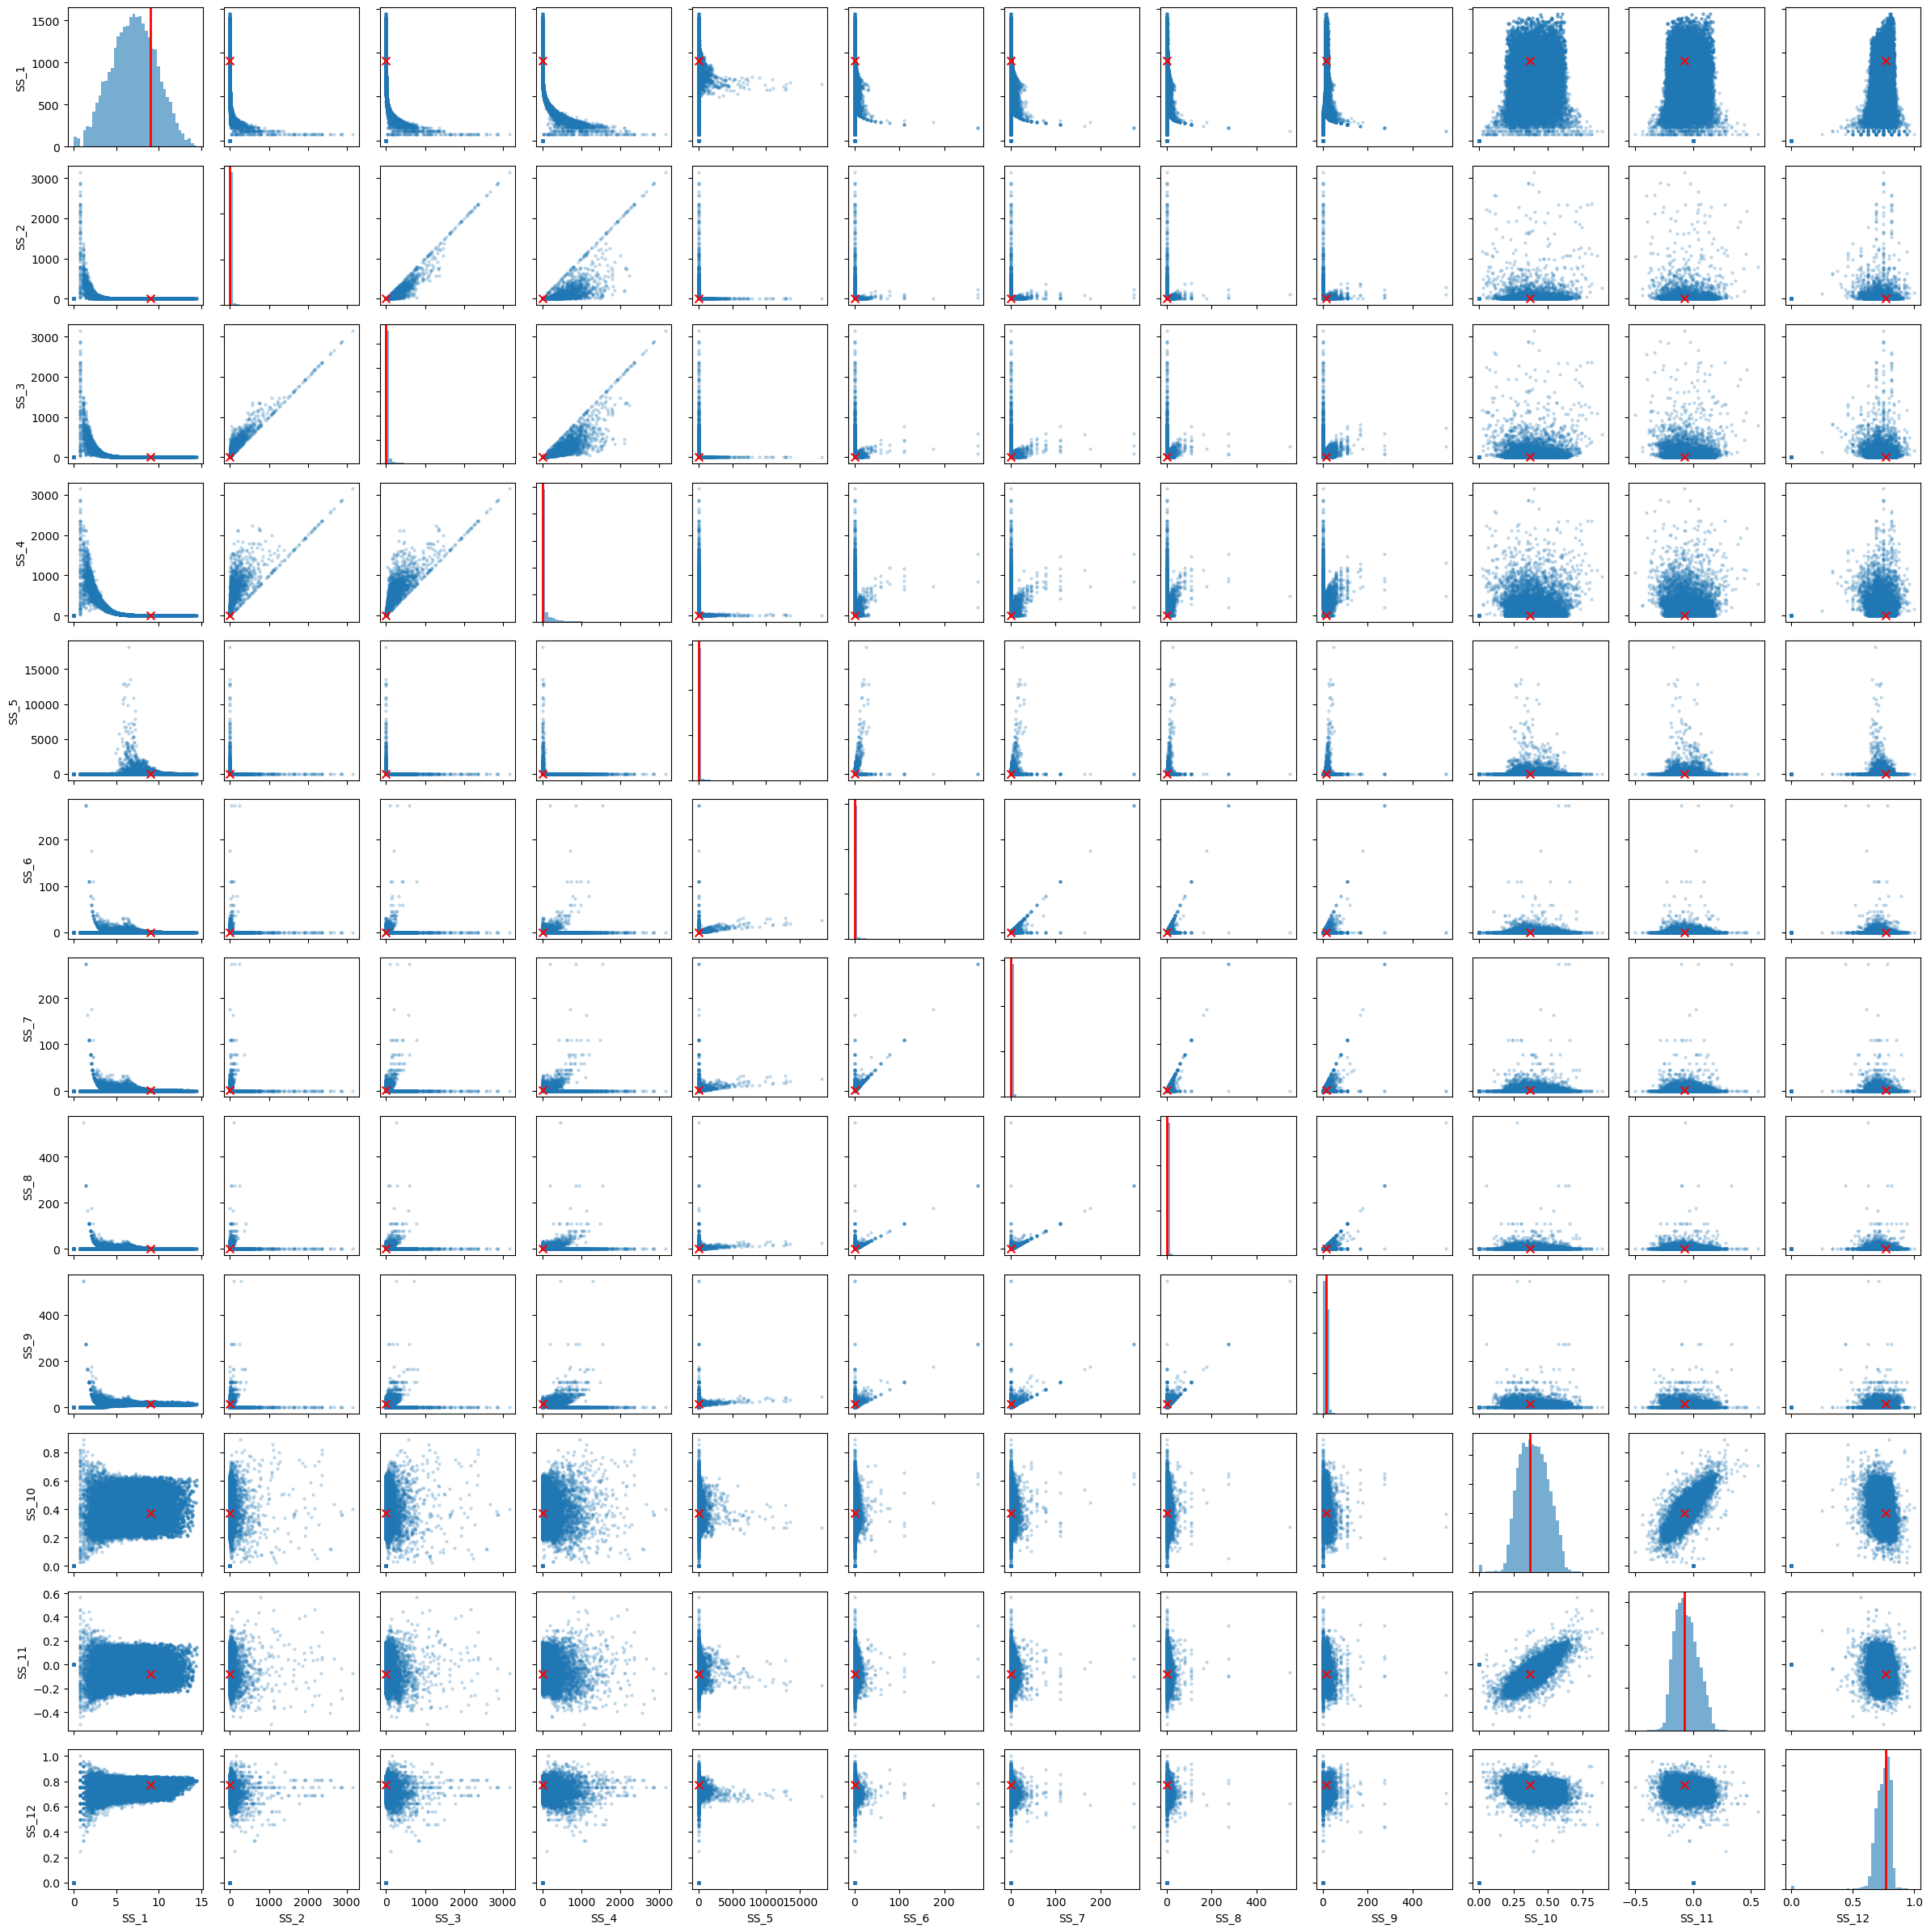

In [12]:

n_stats = SS_0_train.shape[1]
fig, axes = plt.subplots(n_stats, n_stats, figsize=(2*n_stats, 2*n_stats))

for i in range(n_stats):
    for j in range(n_stats):
        ax = axes[i, j]
        if i == j:
            # histogram on diagonal
            #perc = percentileofscore(SS_0_train[:, i], SS_observed[i])
            ax.hist(SS_0_train[:, i], bins=40, alpha=0.6)
            ax.axvline(SS_observed[i], color="red", lw=2)
        else:
            # scatter off-diagonal
            ax.scatter(SS_0_train[:, j], SS_0_train[:, i], s=5, alpha=0.2)
            ax.scatter(SS_observed[j], SS_observed[i], color="red", marker="x", s=50)
        if i < n_stats-1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(f"SS_{j+1}")
        if j > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(f"SS_{i+1}")

plt.tight_layout()
plt.show()

In [17]:
SS_mean = np.mean(SS_0_train, axis=0)
SS_std = np.std(SS_0_train, axis=0)

SS_0_train_normalized = (SS_0_train - SS_mean) / SS_std
SS_0_test_normalized = (SS_0_test - SS_mean) / SS_std

In [18]:
Y_shuffled_train = params_sample_train_NS[:, :-1]
np.random.shuffle(Y_shuffled_train)
Y_shuffled_train = Y_shuffled_train.repeat(K, axis = 0)
params_train = np.concatenate([Y_train, Y_shuffled_train])
params_train_unshuffled_copy = params_train.copy()
response_train = np.concatenate([np.repeat(1, len(Y_train)), np.repeat(0, len(Y_train))])

SS_0_train_normalized_neural = np.concatenate([SS_0_train_normalized, SS_0_train_normalized])

print(SS_0_train_normalized_neural.shape)

#--------------------

Y_shuffled_test = params_sample_test_NS[:, :-1]
np.random.shuffle(Y_shuffled_test)
Y_shuffled_test = Y_shuffled_test.repeat(K, axis = 0)
params_test = np.concatenate([Y_test, Y_shuffled_test])
response_test = np.concatenate([np.repeat(1, len(Y_test)), np.repeat(0, len(Y_test))])

SS_0_test_normalized_neural = np.concatenate([SS_0_test_normalized, SS_0_test_normalized])

print(SS_0_test_normalized_neural.shape)

#--------------------
params_train_not_shuffled = params_sample_train_NS[:, :-1].copy()
SS_0_train_normalized_not_shuffled = SS_0_train_normalized.copy()

params_mean = np.mean(params_train, axis=0)
params_std = np.std(params_train, axis=0)

#--
d_e_false = 1 / (1 + np.mean(((Y_train - params_mean)/params_std - (Y_shuffled_train - params_mean)/params_std)**2, axis = 1))
d_e_false = len(Y_train) * d_e_false / np.sum(d_e_false)
d_e_true = np.ones(len(Y_train))
d_e = np.concatenate([d_e_true, d_e_false])
#--

response_train, params_train, SS_0_train_normalized_neural, d_e = us.shuffle_data(response_train, params_train, SS_0_train_normalized_neural, d_e)
response_test, params_test, SS_0_test_normalized_neural = us.shuffle_data(response_test, params_test, SS_0_test_normalized_neural)

#X_global_mean = np.mean(X_global_train, axis=0)
#X_global_std = np.std(X_global_train, axis=0)

# Normalize the training sets
params_train_normalized = (params_train - params_mean) / params_std

# Normalize the test sets using the training set statistics
params_test_normalized = (params_test - params_mean) / params_std


(60000, 12)
(600, 12)


In [19]:

x_global_input = Input(shape=(gs,))

x = Dense(32, activation='tanh')(x_global_input)
x = Dense(32, activation='tanh')(x)
x = Dense(8, activation='tanh')(x)
output = Dense(len(l_bounds_NS), activation='linear')(x)  

sub_model_NS = Model(x_global_input, output)

# Compile the model
initial_learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=initial_learning_rate)
sub_model_NS.compile(optimizer=optimizer, loss="mse")
sub_model_NS.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,790 (6.99 KB)

 Trainable params: 1,790 (6.99 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 0.6171 - val_loss: 0.3206
Epoch 2/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 320us/step - loss: 0.3133 - val_loss: 0.2633
Epoch 3/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 0.2653 - val_loss: 0.2354
Epoch 4/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 320us/step - loss: 0.2404 - val_loss: 0.2179
Epoch 5/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 0.2230 - val_loss: 0.2082
Epoch 6/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - loss: 0.2085 - val_loss: 0.1988
Epoch 7/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 0.2028 - val_loss: 0.1907
Epoch 8/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 321us/step - loss: 0.1953 - val_loss: 0.1888
Epoch 9/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step - loss: 0.1895 - val_loss: 0.1778
Epoch 10/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 309us/step - loss: 0.1835 - val_loss: 0.1742
Epoch 11/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - loss: 0.1768 - val_loss: 0.1694
Epoch 12/200
270/27

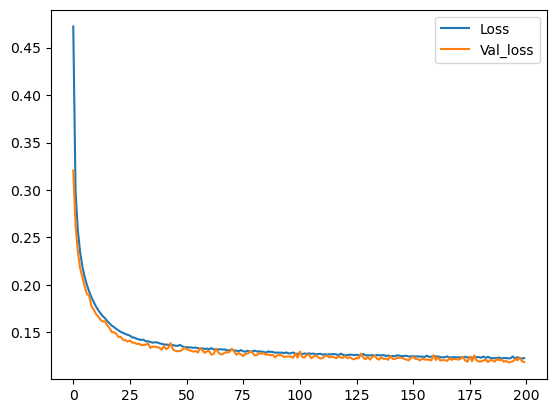

In [20]:
params_train_pre, params_test_pre, X_global_train_pre, X_global_test_pre = params_train_normalized[response_train==1], params_test_normalized[response_test==1], SS_0_train_normalized_neural[response_train==1], SS_0_test_normalized_neural[response_test==1]
ES_NS =keras.callbacks.EarlyStopping("val_loss", patience=15, verbose = 1, restore_best_weights=True)

history = sub_model_NS.fit(X_global_train_pre, params_train_pre, epochs=200, batch_size=100, verbose = 1, validation_split=0.1)

plt.figure()
plt.plot(history.history["loss"], label = "Loss")
plt.plot(history.history["val_loss"], label = "Val_loss")
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


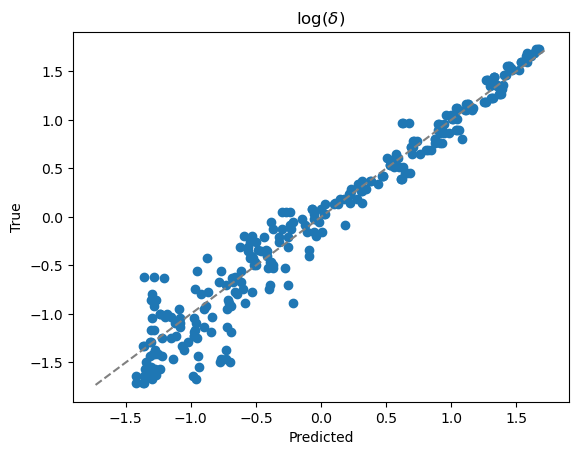

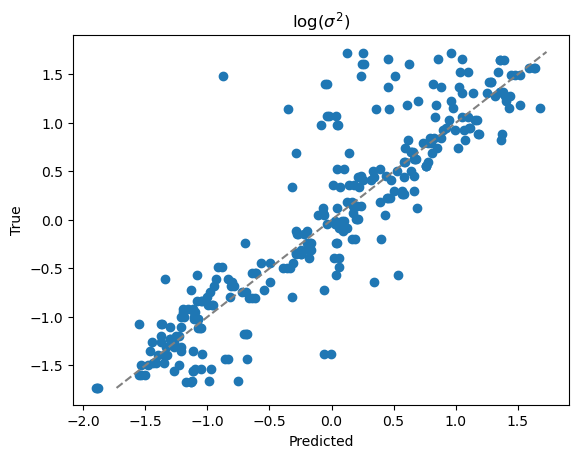

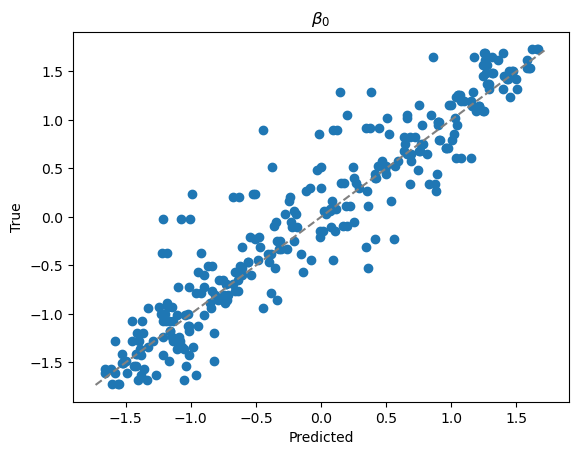

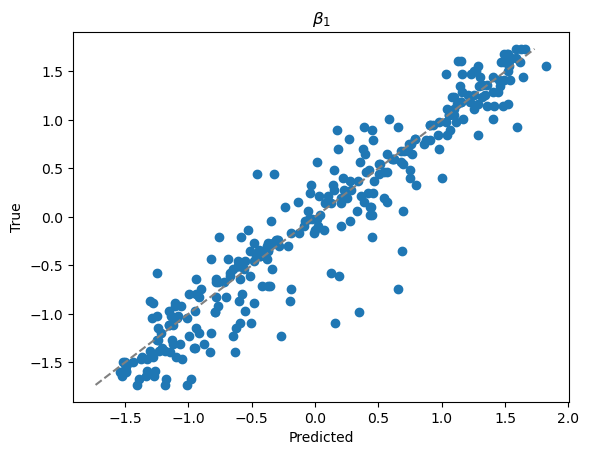

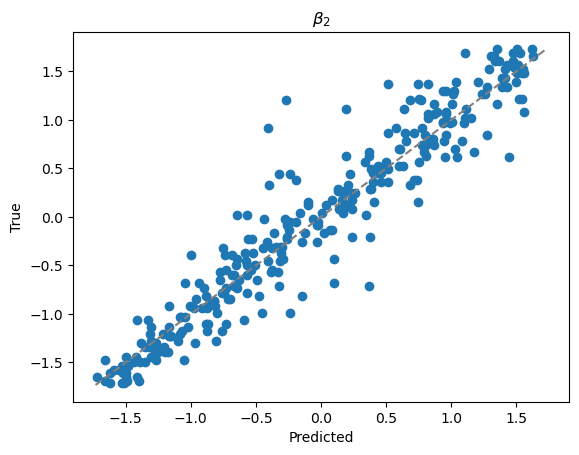

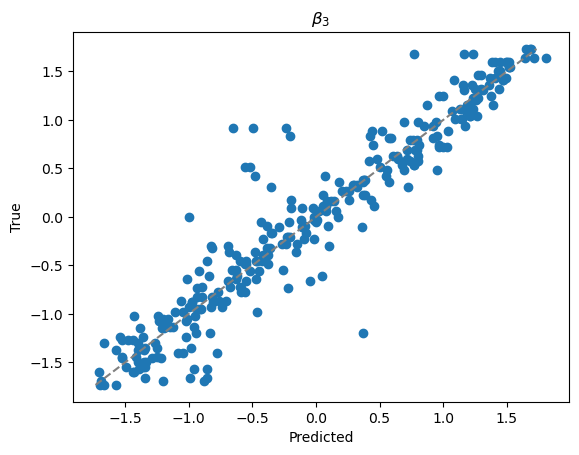

RMSE =  0.32762718337901725


In [21]:
Y_pred = sub_model_NS.predict(X_global_test_pre)
#Y_pred = Y_pred*params_std + params_mean

for dim in range(len(l_bounds_NS)):
    plt.figure()
    plt.title(f"{col_names_params_NS[dim]}")
    plt.scatter(Y_pred[:, dim], params_test_pre[:, dim])
    plt.plot((np.linspace(l_bounds_NS[dim], u_bounds_NS[dim]) - params_mean[dim])/params_std[dim], (np.linspace(l_bounds_NS[dim], u_bounds_NS[dim]) - params_mean[dim])/params_std[dim], linestyle = "--", color = "grey")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

RMSE_neural_point = np.sqrt(np.mean((Y_pred - params_test_pre)**2))
print("RMSE = ", RMSE_neural_point)


In [22]:
sub_model_clone_NS  = keras.models.clone_model(sub_model_NS)
sub_model_clone_NS.set_weights(sub_model_NS.get_weights())
sub_model_clone_NS_cutted = Model(sub_model_clone_NS.inputs, sub_model_clone_NS.layers[-1].output)

for layer in sub_model_clone_NS_cutted.layers:
    layer.trainable = False

Input_summary_statistics = Input(shape=(gs,))
Input_parameters = Input(shape=(len(u_bounds_NS),))

#sub_model_output = sub_model_clone_cutted(Input_summary_statistics)
sub_model_NS_output = Sequential(sub_model_clone_NS_cutted.layers)(Input_summary_statistics)

concatenated = Concatenate(name = "Combine")([Input_summary_statistics, Input_parameters, sub_model_NS_output])

x = Dense(64, activation='tanh', name = "First_dense")(concatenated)
x = Dense(16, activation='tanh')(x)
x = Dense(32, activation='tanh')(x)

output = Dense(1, activation='linear')(x)  

# Model definition
classification_NN_NS = Model([Input_summary_statistics, Input_parameters], output)

# Compile the model
initial_learning_rate = 0.0001

optimizer = keras.optimizers.Adam(learning_rate=initial_learning_rate)
classification_NN_NS.compile(optimizer=optimizer, loss=keras.losses.BinaryCrossentropy(from_logits=True, label_smoothing=0.0))
classification_NN_NS.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 6)         │      1,790 │ input_layer_2[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Combine             │ (None, 24)        │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ input_layer_3[0]… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ First_dense (Dense) │ (None, 64)        │      1,600 │ Combine[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │      1,040 │ First_dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │        544 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         33 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,007 (19.56 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 1,790 (6.99 KB)

Epoch 1/500


/Users/oyvindhs/miniconda3/envs/myenv/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_14', 'keras_tensor_15']. Received: the structure of inputs=('*', '*')
  warnings.warn(


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 366us/step - loss: 0.6953 - val_loss: 0.6598
Epoch 2/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 321us/step - loss: 0.6164 - val_loss: 0.4283
Epoch 3/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 318us/step - loss: 0.3700 - val_loss: 0.2406
Epoch 4/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 314us/step - loss: 0.2178 - val_loss: 0.1526
Epoch 5/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 333us/step - loss: 0.1409 - val_loss: 0.1053
Epoch 6/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 325us/step - loss: 0.1007 - val_loss: 0.0785
Epoch 7/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 318us/step - loss: 0.0756 - val_loss: 0.0622
Epoch 8/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 330us/step - loss: 0.0608 - val_loss: 0.0536
Epoch 9/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 311us/step - loss: 0.0538 - val_loss: 0.0444
Epoch 10/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 311us/step - loss: 0.0448 - val_loss: 0.0397
Epoch 11/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 310us/step - loss: 0.0412 - val_loss: 0.0380
Epoch 12/

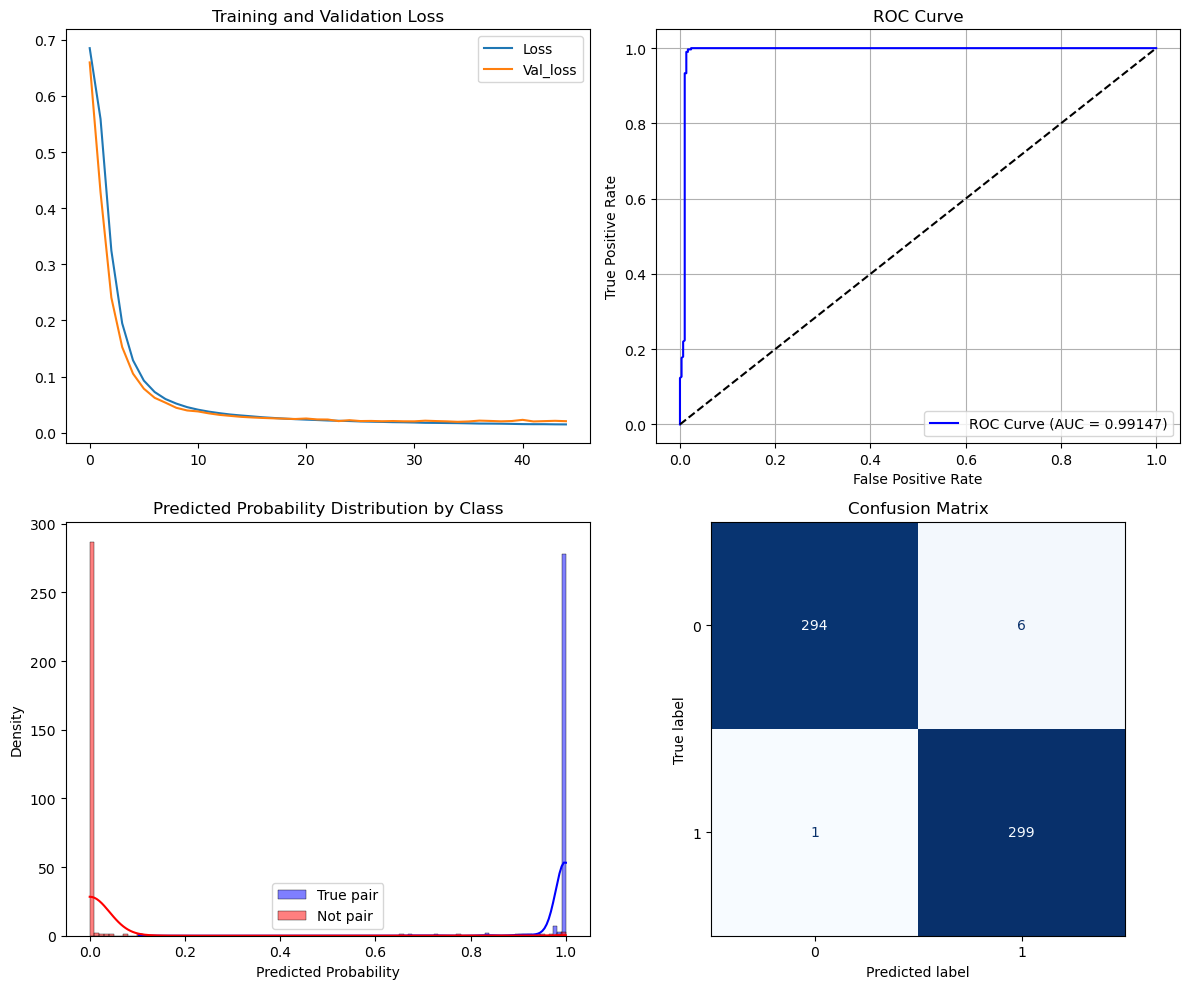

In [23]:
#classification_NN_NS.optimizer.learning_rate.assign(0.001)
ES =keras.callbacks.EarlyStopping("val_loss", patience=10, verbose = 1, restore_best_weights=True)
history = classification_NN_NS.fit([SS_0_train_normalized_neural, params_train_normalized], response_train, epochs=500, batch_size=32, verbose = 1, validation_split=0.1, callbacks=[ES])#sample_weight=d_e)

response_test_pred_logits = classification_NN_NS.predict([SS_0_test_normalized_neural, params_test_normalized]).reshape((-1))
response_test_pred_probs = 1 / (1 + np.exp(-response_test_pred_logits))

fpr, tpr, _ = roc_curve(response_test, response_test_pred_probs)
roc_auc = auc(fpr, tpr)

# Confusion matrix
response_test_pred = (response_test_pred_probs >= 0.5).astype(int)
cm = confusion_matrix(response_test, response_test_pred)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

# Loss plot
axs[0].plot(history.history["loss"], label="Loss")
axs[0].plot(history.history["val_loss"], label="Val_loss")
axs[0].set_title("Training and Validation Loss")
axs[0].legend()

# ROC curve
axs[1].plot(fpr, tpr, color='b', label=f'ROC Curve (AUC = {roc_auc:.5f})')
axs[1].plot([0, 1], [0, 1], 'k--')
axs[1].set_xlabel('False Positive Rate')
axs[1].set_ylabel('True Positive Rate')
axs[1].set_title('ROC Curve')
axs[1].legend()
axs[1].grid()

# Histogram of predicted probabilities
sns.histplot(response_test_pred_probs[response_test == 1], color='b', label='True pair', kde=True, bins=100, ax=axs[2])
sns.histplot(response_test_pred_probs[response_test == 0], color='r', label='Not pair', kde=True, bins=100, ax=axs[2])
axs[2].set_xlabel('Predicted Probability')
axs[2].set_ylabel('Density')
axs[2].set_title('Predicted Probability Distribution by Class')
axs[2].legend()

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(ax=axs[3], cmap=plt.cm.Blues, colorbar=False)
axs[3].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [1]:
importlib.reload(us)
np.random.seed(42)
n_samples = response_test_pred_probs.shape[0]

logit_h = response_test_pred_logits

X_platt = logit_h.reshape(-1, 1)
model_calibration = LogisticRegression()
model_calibration.fit(X_platt, response_test) 
platt_scaler = model_calibration.coef_[0][0]
print(f"Model Coefficients: β0 = {model_calibration.intercept_[0]:.4f}, β1 = {model_calibration.coef_[0][0]:.4f}")

NameError: name 'importlib' is not defined

## Åknes inference


In [25]:
SS_observed_normalized = (SS_observed-SS_mean)/SS_std
N_grid = 10000
grid = us.LHS(N_grid, l_bounds_NS, u_bounds_NS, years)[:,:-1]
grid_norm = (grid - params_mean) / params_std

ll_grid_NS = classification_NN_NS.predict([SS_observed_normalized.reshape((1,-1)).repeat(len(grid_norm), axis = 0), grid_norm]).reshape(-1)  
start = grid_norm[np.argmax(ll_grid_NS)]
MLE_observed, MLE_observed_norm, final_logit_NS, _, _ =  us.numerical_optim(start, SS_observed_normalized, l_bounds_NS, u_bounds_NS, classification_NN_NS, gs, params_mean=params_mean, params_std=params_std)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step
Grad good
Optimized z: [ 1.65309852 -0.12253054 -1.526329   -0.76105508 -0.36454836  1.49614579]
Gradient norm: 9.758914e-10
Inside: True
Steps: 821


In [26]:
print(l_bounds_NS)
print(u_bounds_NS)

[-4.60517019 -6.90775528 -3.         -2.         -2.         -1.        ]
[2.30258509 0.         2.         1.         1.         3.        ]


In [46]:
def godambe_G_NS(N_G, theta_0, params_mean, params_std, gs, year, p, plot = False):

    theta_0_repeated = np.repeat(np.reshape(theta_0, (1,-1)), N_G, axis = 0)
    theta_0_repeated_shape = np.zeros((theta_0_repeated.shape[0], theta_0_repeated.shape[1]+1))
    theta_0_repeated_shape[:, :-1] = theta_0_repeated
    theta_0_repeated_shape[:, -1] = np.repeat(year, theta_0_repeated.shape[0])

    SS_observed_bootstrap =  np.zeros((N_G, gs))
    X_boot, Y_boot, metro_year_list_train_boot, invalid_index_train = us.simulate_given_params(J=N_G, K=1, T=T, p=p, df_metro = df_metro, params=theta_0_repeated_shape, error = 0)

    for i in range(len(theta_0_repeated)):
        SS_observed_bootstrap[i,:] = us.summary_statistics(X_boot[i], T, cluster_bins, percentiles, df_metro, metro_year_list_train_boot[i], verbose=False, p = p)


    SS_observed_bootstrap_norm = (SS_observed_bootstrap - SS_mean) / SS_std

    H = np.zeros((p,p))
    J = np.zeros((p,p))
    U_ray = []

    theta_0_normalized = (theta_0 - params_mean)/params_std
    norm_change = []
    for n in range(N_G):
        h, U = us.get_neg_hessian(theta_0_normalized, SS_observed_bootstrap_norm[n], gs, len(params_mean), classification_NN_NS)
        H += h
        J += np.outer(U, U)
        U_ray.append(U)
        if plot and n!=0:
            H_temp = H/n
            J_temp = J/n
            norm_change.append([np.trace(H_temp), np.trace(J_temp)])

    H = H/N_G
    J = J/N_G
    H_inv = np.linalg.inv(H)
    G = np.dot(np.dot(H_inv, J), H_inv)
    norm_change = np.array(norm_change)

    if plot:
        plt.figure()
        plt.plot(norm_change[:, 0], label = "trace(H)")
        plt.plot(norm_change[:, 1], label = "trace(J)")
        plt.legend()
        plt.show()
    return G, H

0 / 70
1 / 70
2 / 70
3 / 70
4 / 70
5 / 70
6 / 70
7 / 70
8 / 70
9 / 70
10 / 70
11 / 70
12 / 70
13 / 70
14 / 70
15 / 70
16 / 70
17 / 70
18 / 70
19 / 70
20 / 70
21 / 70
22 / 70
23 / 70
24 / 70
25 / 70
26 / 70
27 / 70
28 / 70
29 / 70
30 / 70
31 / 70
32 / 70
33 / 70
34 / 70
35 / 70
36 / 70
37 / 70
38 / 70
39 / 70
40 / 70
41 / 70
42 / 70
43 / 70
44 / 70
45 / 70
46 / 70
47 / 70
48 / 70
49 / 70
50 / 70
51 / 70
52 / 70
53 / 70
54 / 70
55 / 70
56 / 70
57 / 70
58 / 70
59 / 70
60 / 70
61 / 70
62 / 70
63 / 70
64 / 70
65 / 70
66 / 70
67 / 70
68 / 70
69 / 70


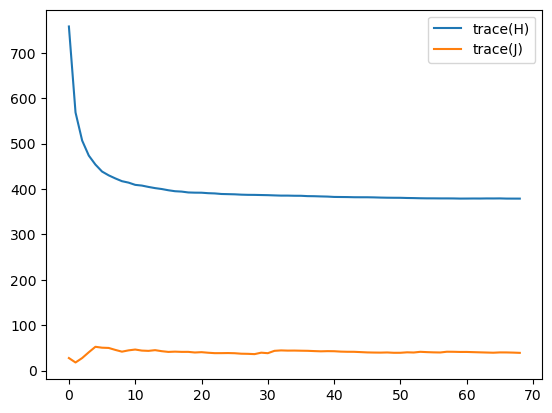

In [28]:
N_G = 70
G_inv_NS, H_neg_NS_mean = godambe_G_NS(N_G, MLE_observed.reshape((1,-1)), params_mean, params_std, year = years[0], gs = gs, p = p, plot = True)
H_neg_NS, _ = us.get_neg_hessian(MLE_observed_norm, SS_observed_normalized, gs, len(params_mean), classification_NN_NS)

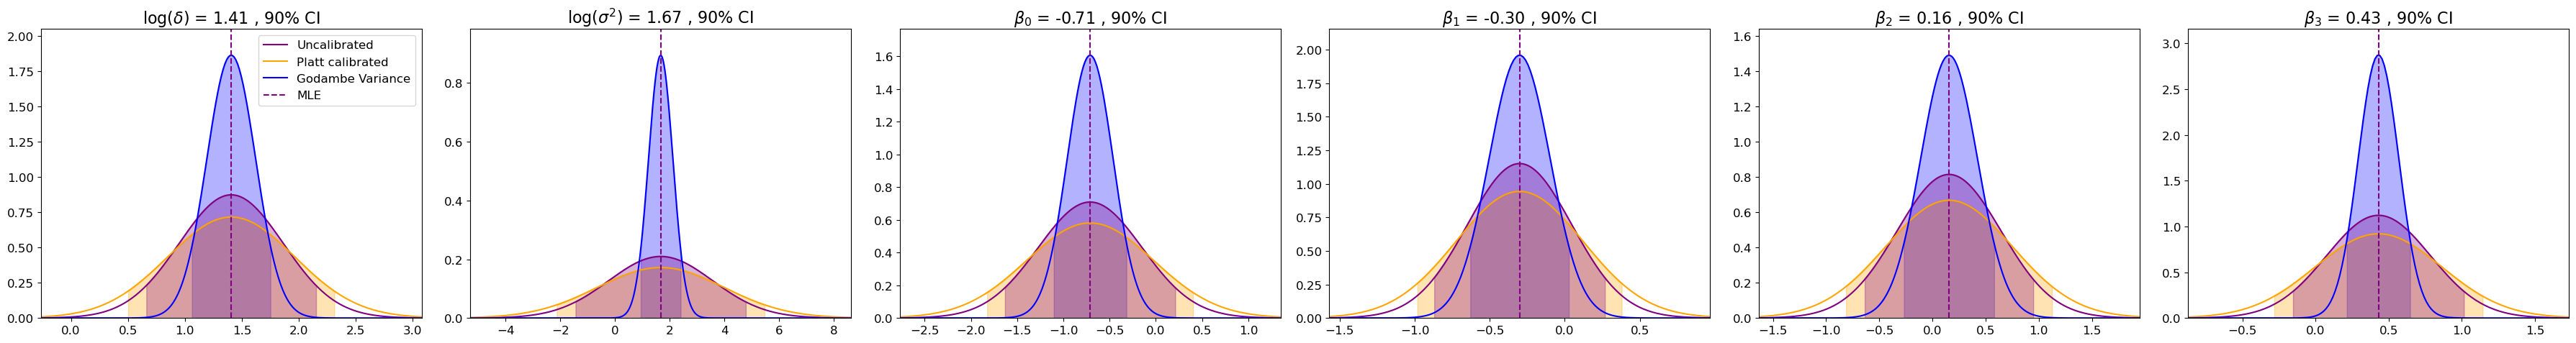

In [29]:
plt.rcParams.update({
    "font.size": 14,        # default text
    "axes.titlesize": 16,   # title
    "axes.labelsize": 14,   # x and y labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

fig, axs = plt.subplots(1, len(MLE_observed_norm), figsize=(6 * len(MLE_observed_norm), 5))

w = 8
k = 0.5
resolution = 1000
alpha = 0.1
for dim in range(len(MLE_observed_norm)):
    dim_vary = np.linspace(MLE_observed_norm[dim] - w, MLE_observed_norm[dim] + w, resolution)
    #dim_vary = np.linspace(l_bounds[dim], u_bounds[dim], resolution)
    full_dim = MLE_observed_norm.reshape((1, -1)).repeat(resolution, axis = 0)
    full_dim[:, dim] = dim_vary
    full_dim_norm = full_dim#(full_dim-params_mean)/params_std 
    ax = axs[dim] if len(MLE_observed_norm) > 1 else axs

    #Gaussian pdf
    mu = MLE_observed_norm[dim]
    std_G = np.sqrt(G_inv_NS[dim][dim])
    std = np.sqrt(np.linalg.inv(H_neg_NS)[dim][dim])
    std_Platt = np.sqrt(np.linalg.inv(H_neg_NS*platt_scaler)[dim][dim])

    pdf_G = norm.pdf(dim_vary, loc = mu, scale = std_G)
    pdf = norm.pdf(dim_vary, loc=mu, scale=std)
    pdf_Platt = norm.pdf(dim_vary, loc=mu, scale=std_Platt)

    # CI
    z = norm.ppf(1 - alpha/2)
    lower, upper =  mu- z*std, mu + z*std
    inside = (dim_vary >= lower) & (dim_vary <= upper)

    lower, upper = mu - z*std_G, mu + z*std_G
    inside_G = (dim_vary >= lower) & (dim_vary <= upper)

    lower, upper = mu - z*std_Platt, mu + z*std_Platt
    inside_platt = (dim_vary >= lower) & (dim_vary <= upper)


    ax.set_title(f"{col_names_params_NS[dim]} = {MLE_observed_norm[dim]:.2f} , {100-alpha*100:.0f}% CI") #({np.min(full_dim_norm[inside, dim]):.2f}, {np.max(full_dim_norm[inside, dim]):.2f})
    ax.plot(dim_vary, pdf, label="Uncalibrated", color="purple")
    ax.plot(dim_vary, pdf_Platt, label="Platt calibrated", color="orange")
    ax.plot(dim_vary, pdf_G, label="Godambe Variance", color="blue")

    ymin = 0
    ymax = np.max([np.max(pdf), np.max(pdf_G), np.max(pdf_Platt)])


    #ax.fill_between(dim_vary, Z_0, y2=ymin, where=inside, color='purple', alpha=0.3, label=f'{alpha*100:.0f}% CI')
    ax.fill_between(dim_vary, pdf_G, y2=ymin, where=inside_G, color='blue', alpha=0.3)
    ax.fill_between(dim_vary, pdf_Platt, y2=ymin, where=inside_platt, color='orange', alpha=0.3)
    ax.fill_between(dim_vary, pdf, y2=ymin, where=inside, color='purple', alpha=0.3)


    ax.vlines(x=MLE_observed_norm[dim], ymax=ymax*1.1, ymin=ymin, linestyles="--", color="purple", label="MLE")

    ax.set_xlim((mu - np.max([std, std_Platt, std_G])*3, mu + np.max([std, std_Platt, std_G])*3))
    ax.set_ylim((ymin, ymax*1.1))
    if dim == 0:
        ax.legend()
plt.tight_layout()

plt.show()

In [43]:
z = norm.ppf(1 - alpha/2)
std_G = np.sqrt(G_inv_NS[np.diag_indices_from(G_inv_NS)])
print(f"{MLE_observed - std_G*z/params_std}",  f"{MLE_observed + std_G*z/params_std}")
"""
H_platt_temp = np.sqrt(np.linalg.inv(H_neg_NS*platt_scaler))
std_Platt = np.sqrt(H_platt_temp[np.diag_indices_from(H_platt_temp)])
print(f"{MLE_observed - std_Platt*z/params_std}",  f"{MLE_observed + std_Platt*z/params_std}")

H_temp = np.sqrt(np.linalg.inv(H_neg_NS))
std = np.sqrt(H_temp[np.diag_indices_from(H_temp)])
print(f"{MLE_observed - std*z/params_std}",  f"{MLE_observed + std*z/params_std}")
"""

[ 1.47664023 -0.49053713 -1.80919887 -1.14792559 -0.8724212   1.29832086] [ 1.82955682  0.24547604 -1.24345913 -0.37418457  0.14332449  1.69397073]


'\nH_platt_temp = np.sqrt(np.linalg.inv(H_neg_NS*platt_scaler))\nstd_Platt = np.sqrt(H_platt_temp[np.diag_indices_from(H_platt_temp)])\nprint(f"{MLE_observed - std_Platt*z/params_std}",  f"{MLE_observed + std_Platt*z/params_std}")\n\nH_temp = np.sqrt(np.linalg.inv(H_neg_NS))\nstd = np.sqrt(H_temp[np.diag_indices_from(H_temp)])\nprint(f"{MLE_observed - std*z/params_std}",  f"{MLE_observed + std*z/params_std}")\n'

In [41]:
MLE_observed

array([ 1.65309852, -0.12253054, -1.526329  , -0.76105508, -0.36454836,
        1.49614579])

In [42]:
np.exp(1.65)

5.206979827179849

In [32]:
print((l_bounds_NS - params_mean)/params_std)
print((u_bounds_NS - params_mean)/params_std)

print(l_bounds_NS)
print(u_bounds_NS)

[-1.73205219 -1.73204783 -1.73205209 -1.7320523  -1.73205102 -1.73204952]
[1.73205052 1.73205177 1.73205364 1.73205069 1.73205115 1.73205157]
[-4.60517019 -6.90775528 -3.         -2.         -2.         -1.        ]
[2.30258509 0.         2.         1.         1.         3.        ]


# Visualize fit

In [33]:
params_MLE = np.append(MLE_observed, 0)
N_boot = 1000
X_MLE_sim, Y_MLE_sim, _, _ = us.simulate_given_params(1,1,T, p, df_metro, np.repeat(params_MLE.reshape((1, -1)), N_boot, axis = 0))

0 / 1000
1 / 1000
2 / 1000
3 / 1000
4 / 1000
5 / 1000
6 / 1000
7 / 1000
8 / 1000
9 / 1000
10 / 1000
11 / 1000
12 / 1000
13 / 1000
14 / 1000
15 / 1000
16 / 1000
17 / 1000
18 / 1000
19 / 1000
20 / 1000
21 / 1000
22 / 1000
23 / 1000
24 / 1000
25 / 1000
26 / 1000
27 / 1000
28 / 1000
29 / 1000
30 / 1000
31 / 1000
32 / 1000
33 / 1000
34 / 1000
35 / 1000
36 / 1000
37 / 1000
38 / 1000
39 / 1000
40 / 1000
41 / 1000
42 / 1000
43 / 1000
44 / 1000
45 / 1000
46 / 1000
47 / 1000
48 / 1000
49 / 1000
50 / 1000
51 / 1000
52 / 1000
53 / 1000
54 / 1000
55 / 1000
56 / 1000
57 / 1000
58 / 1000
59 / 1000
60 / 1000
61 / 1000
62 / 1000
63 / 1000
64 / 1000
65 / 1000
66 / 1000
67 / 1000
68 / 1000
69 / 1000
70 / 1000
71 / 1000
72 / 1000
73 / 1000
74 / 1000
75 / 1000
76 / 1000
77 / 1000
78 / 1000
79 / 1000
80 / 1000
81 / 1000
82 / 1000
83 / 1000
84 / 1000
85 / 1000
86 / 1000
87 / 1000
88 / 1000
89 / 1000
90 / 1000
91 / 1000
92 / 1000
93 / 1000
94 / 1000
95 / 1000
96 / 1000
97 / 1000
98 / 1000
99 / 1000
100 / 1000

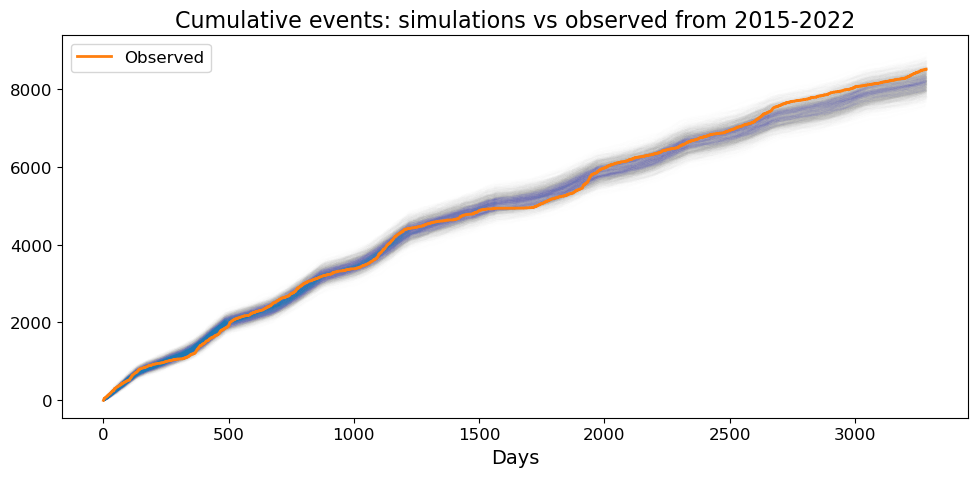

In [ ]:
# Assume:
# X_MLE_sim: list of arrays of event times (timestamps) for each simulation
# X_observed: array of observed event times (timestamps)

plt.figure(figsize=(10,5))

# Plot simulations
for sim_times in X_MLE_sim:
    print
    sim_times_sorted = np.sort(sim_times)
    cum_counts = np.arange(1, len(sim_times_sorted)+1)
    plt.step(sim_times_sorted, cum_counts, color="tab:blue", alpha=0.005)

# Plot observed
obs_sorted = np.sort(X_observed)
cum_obs = np.arange(1, len(obs_sorted)+1)
plt.step(obs_sorted, cum_obs, color="tab:orange", lw=2, label="Observed")

plt.xlabel("Days")
#plt.ylabel("Cumulative number of events")
plt.title("Cumulative events: simulations vs observed from 2015-2022")
plt.legend()
plt.tight_layout()
plt.show()

# Åknes test

In [85]:
#years_test = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
years_test = [2023]


mask = timestamps.year.isin(years_test)
X_observed_test = timestamps[mask]
t0 = X_observed_test.min()
X_observed_test = (X_observed_test - t0).total_seconds() / 86400.0
X_observed_test = X_observed_test.to_numpy()


In [762]:
importlib.reload(us)

params_MLE_test = np.append(MLE_observed, 2023)

X_MLE_sim_test, Y_MLE_sim_test, _, _ = us.simulate_given_params(1,1,365, p, df_metro, np.repeat(params_MLE_test.reshape((1, -1)), 100, axis = 0))

0 / 100
1 / 100
2 / 100
3 / 100
4 / 100
5 / 100
6 / 100
7 / 100
8 / 100
9 / 100
10 / 100
11 / 100
12 / 100
13 / 100
14 / 100
15 / 100
16 / 100
17 / 100
18 / 100
19 / 100
20 / 100
21 / 100
22 / 100
23 / 100
24 / 100
25 / 100
26 / 100
27 / 100
28 / 100
29 / 100
30 / 100
31 / 100
32 / 100
33 / 100
34 / 100
35 / 100
36 / 100
37 / 100
38 / 100
39 / 100
40 / 100
41 / 100
42 / 100
43 / 100
44 / 100
45 / 100
46 / 100
47 / 100
48 / 100
49 / 100
50 / 100
51 / 100
52 / 100
53 / 100
54 / 100
55 / 100
56 / 100
57 / 100
58 / 100
59 / 100
60 / 100
61 / 100
62 / 100
63 / 100
64 / 100
65 / 100
66 / 100
67 / 100
68 / 100
69 / 100
70 / 100
71 / 100
72 / 100
73 / 100
74 / 100
75 / 100
76 / 100
77 / 100
78 / 100
79 / 100
80 / 100
81 / 100
82 / 100
83 / 100
84 / 100
85 / 100
86 / 100
87 / 100
88 / 100
89 / 100
90 / 100
91 / 100
92 / 100
93 / 100
94 / 100
95 / 100
96 / 100
97 / 100
98 / 100
99 / 100


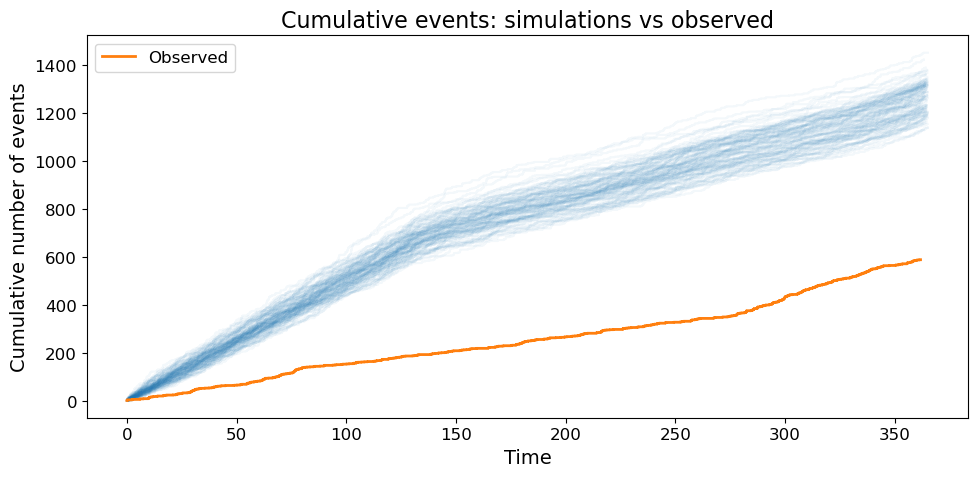

In [763]:
# Assume:
# X_MLE_sim: list of arrays of event times (timestamps) for each simulation
# X_observed: array of observed event times (timestamps)

plt.figure(figsize=(10,5))

# Plot simulations
for sim_times in X_MLE_sim_test:
    print
    sim_times_sorted = np.sort(sim_times)
    cum_counts = np.arange(1, len(sim_times_sorted)+1)
    plt.step(sim_times_sorted, cum_counts, color="tab:blue", alpha=0.05)

# Plot observed
obs_sorted = np.sort(X_observed_test)
cum_obs = np.arange(1, len(obs_sorted)+1)
plt.step(obs_sorted, cum_obs, color="tab:orange", lw=2, label="Observed")

plt.xlabel("Time")
plt.ylabel("Cumulative number of events")
plt.title("Cumulative events: simulations vs observed")
plt.legend()
plt.tight_layout()
plt.show()

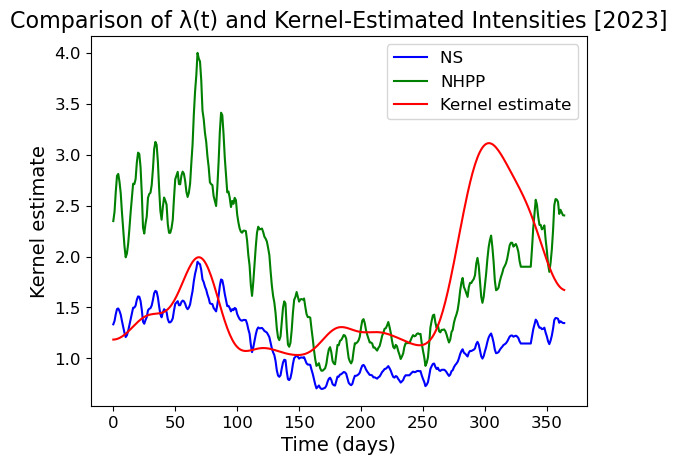

In [ ]:
importlib.reload(us)

#year_str = str(year_observed)
T_test = 365
X_cov = us.covariate_formater(df_metro, years_test, x_p = p - 3, T = T_test)

lambda_fitted = np.array([us.lambda_intensity(t, X_cov, MLE_observed[2:], error = 0) for t in range(T_test)]) * np.exp(MLE_observed[0])

kernel_density_estimate = us.kernel_intensity_estimate_reflect(X_observed_test, 14, domain= (0, T_test))

lam_fit = intensity(res.x, df_design[df_design.index.year.isin(years_test)].drop(columns="time").values)

tt = np.arange(0, T_test, 1)
fig, ax1 = plt.subplots()

ax1.plot(tt, lambda_fitted, 'b-', label='NS ')
ax1.plot(tt, lam_fit, 'g-', label='NHPP')

ax1.set_ylabel('λ_fitted')
ax1.tick_params(axis='y')

ax1.plot(tt, kernel_density_estimate, 'r-', label='Kernel estimate')
ax1.set_ylabel('Kernel estimate')
plt.legend()
plt.xlabel('Time (days)')
plt.title(f'Comparison of λ(t) and Kernel-Estimated Intensities {years_test}')
plt.show()


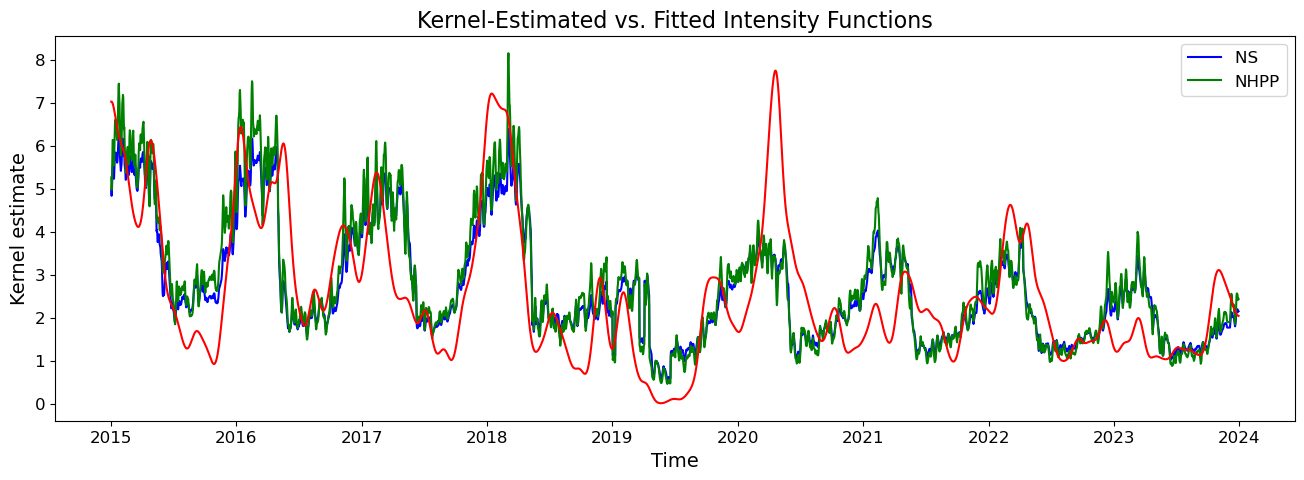

In [138]:
importlib.reload(us)

#year_str = str(year_observed)
X_cov = us.covariate_formater(df_metro, years, x_p = p - 3, T = T)

lambda_fitted = np.array([us.lambda_intensity(t, X_cov, MLE_observed[2:], error = 0) for t in range(T)]) * np.exp(MLE_observed[0])

kernel_density_estimate = us.kernel_intensity_estimate_reflect(X_observed, 14, domain= (0, T))

lam_fit = intensity(res.x, df_design[df_design.index.year.isin(years)].drop(columns="time").values)

tt = np.arange(0, T, 1)
tt = pd.date_range(start=timestamps[timestamps.year.isin(years)][0], periods=T, freq="D")
fig, ax1 = plt.subplots(figsize=(16, 5))  # width=16, height=5

ax1.plot(tt, lambda_fitted, 'b-', label='NS ')
ax1.plot(tt, lam_fit[:T], 'g-', label='NHPP')

ax1.set_ylabel('λ_fitted')
ax1.tick_params(axis='y')

ax1.plot(tt, kernel_density_estimate, 'r-', label='')
ax1.set_ylabel('Kernel estimate')
plt.legend()
plt.xlabel('Time')
plt.title(f'Kernel-Estimated vs. Fitted Intensity Functions')
plt.show()


In [46]:
r_K = 10**(np.linspace(-3, 0, 10))
R_K_observed = us.ripley_K_1D_SS_test(X_observed, r_K, T)
R_K_NS = np.array([us.ripley_K_1D_SS_test(X_MLE_sim[i], r_K, T) for i in range(len(X_MLE_sim))])


In [47]:
def simulate_nhpp_piecewise(params, X, T):
    """
    Simulate NHPP on (0, T) with piecewise-constant intensity.
    
    params : array (p,)
    X      : array (T, p), covariates at integer times 0,...,T-1
    T      : integer, end of interval
    """
    arrivals = []
    lam = intensity(params, X)
    
    for k in range(T):
        Nk = np.random.poisson(lam[k])  # number of events in [k, k+1)
        if Nk > 0:
            arrivals_k = k + np.random.rand(Nk)  # uniform inside interval
            arrivals.extend(arrivals_k)
    
    return np.sort(np.array(arrivals))

X = df_design.drop(columns="time").values  # shape (T, p)

X_MLE_sim_NHPP = [simulate_nhpp_piecewise(res.x, X, T) for i in range(N_boot)]
R_K_NHPP = np.array([us.ripley_K_1D_SS_test(X_MLE_sim_NHPP[i], r_K, T) for i in range(len(X_MLE_sim_NHPP))])


In [48]:
lmbda = len(X_observed)/T
X_MLE_sim_P = []
for i in range(N_boot):
    t, arrivals = 0, []
    while True:
        t += np.random.exponential(1/lmbda)  # inter-arrival time
        if t > T:
            break
        arrivals.append(t)
    arrivals =  np.array(arrivals)
    X_MLE_sim_P.append(arrivals)
    
R_K_P = np.array([us.ripley_K_1D_SS_test(X_MLE_sim_P[i], r_K, T) for i in range(len(X_MLE_sim_P))])


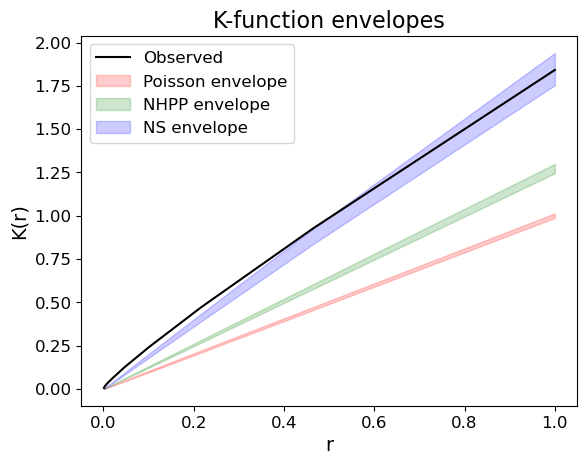

In [49]:
# Compute envelopes
lower_P = np.percentile(R_K_P, 2.5, axis=0)
upper_P = np.percentile(R_K_P, 97.5, axis=0)

lower_NHPP = np.percentile(R_K_NHPP, 2.5, axis=0)
upper_NHPP = np.percentile(R_K_NHPP, 97.5, axis=0)

lower_NS = np.percentile(R_K_NS, 2.5, axis=0)
upper_NS = np.percentile(R_K_NS, 97.5, axis=0)

plt.figure()
plt.plot(r_K, R_K_observed, 'k-', label="Observed")

# Envelope for Poisson simulations
plt.fill_between(r_K, lower_P, upper_P, color="red", alpha=0.2, label="Poisson envelope")

# Envelope for NHPP simulations
plt.fill_between(r_K, lower_NHPP, upper_NHPP, color="green", alpha=0.2, label="NHPP envelope")

# Envelope for Neyman–Scott simulations
plt.fill_between(r_K, lower_NS, upper_NS, color="blue", alpha=0.2, label="NS envelope")

plt.legend()
plt.xlabel("r")
plt.ylabel("K(r)")
plt.title("K-function envelopes")
plt.show()

# Hawkes process


# Hawkes Process with Covariates

The intensity is
$$
\lambda(t) = \mu + \beta x(t) + \sum_{t_i < t} \alpha e^{-\delta (t - t_i)} .
$$

- **Baseline ($\mu$)**: constant background rate.  
- **Covariate effect ($\beta$)**: scales external signal $x(t)$; positive $\beta$ increases rate, negative decreases it.  
- **Excitation size ($\alpha$)**: jump in intensity after each event (clustering strength).  
- **Decay rate ($\delta$)**: speed at which excitation fades; small $\delta$ = long memory, large $\delta$ = short memory.  

In [47]:

def loglik_hawkes(params, events, cov_times, X, T):
    """
    params = [beta_0, beta_1, ..., beta_p, alpha, delta]
      - beta_* are baseline coefficients
      - alpha, delta are Hawkes kernel params
    X : (n_times, p) covariates
    """
    p = X.shape[1]
    beta = np.array(params[:p+1])  # incl intercept
    alpha, delta = params[p+1:]
    
    # -----------------------
    # 1) integral term
    # -----------------------
    dx = np.diff(cov_times)
    linpred = beta[0] + X[:-1] @ beta[1:]
    cov_integral = np.sum(np.exp(linpred) * dx)

    kernel_integral = np.sum((1 - np.exp(-delta * (T - events))) / delta)
    integral = cov_integral + alpha * kernel_integral

    # -----------------------
    # 2) log intensity at events
    # -----------------------
    log_lambda = 0.0
    h = 0.0
    prev_t = 0.0
    for t in events:
        h = h * np.exp(-delta * (t - prev_t))
        x_t = X[int(t),:]
        lam = np.exp(beta[0] + x_t @ beta[1:]) + alpha * h
        h +=1
        if lam <= 0:
            return np.inf
        log_lambda += np.log(lam)
        prev_t = t
    return -(log_lambda - integral)


In [48]:

dt = 1.
cov_times = np.arange(0, T, dt)  # breakpoint
X_hawkes = df_design.drop(columns=["time", "intercept"]).values[:T]
init_params = np.array([0.1, 0.1, 0.1, 0.1, 0.5, 1.0]) #(beta), alpha, delta

# bounds: mu, beta, alpha >=0, delta >0
bounds = [(None, None), (None, None),(None, None),(None, None),(1e-6, None), (1e-6, None)]

res_hawkes = minimize(loglik_hawkes, init_params, args=(X_observed, cov_times, X_hawkes, T), bounds=bounds, method='L-BFGS-B')
print("Estimated parameters:", res_hawkes.x)
print("LogLik = ", loglik_hawkes(res_hawkes.x, X_observed, cov_times, X_hawkes, T))

print("Branching ratio:", res_hawkes.x[-2]/res_hawkes.x[-1], "\n")

for i, col in enumerate(df_design.drop(columns=["time", "intercept"]).columns):
    print(col, res_hawkes.x[i+1])

Estimated parameters: [-1.01418196 -0.43655366 -0.58592452  1.51459542  0.84022591  1.26303561]
LogLik =  -1733.0954523422006
Branching ratio: 0.6652432505266589 

temperature -0.4365536593182065
wp -0.5859245184071254
N_geophones 1.5145954199108005


In [49]:

from math import sqrt

def hessian_fd(func, x0, eps=1e-5):
    """Central-difference Hessian (symmetric). func(x) returns scalar."""
    x0 = np.asarray(x0, dtype=float)
    n = x0.size
    H = np.zeros((n, n), dtype=float)
    fx = func(x0)
    for i in range(n):
        ei = np.zeros(n); ei[i] = 1.0
        for j in range(i, n):
            ej = np.zeros(n); ej[j] = 1.0
            if i == j:
                f1 = func(x0 + eps*ei)
                f2 = func(x0 - eps*ei)
                H[i, i] = (f1 - 2.0*fx + f2) / (eps*eps)
            else:
                fpp = func(x0 + eps*ei + eps*ej)
                fpm = func(x0 + eps*ei - eps*ej)
                fmp = func(x0 - eps*ei + eps*ej)
                fmm = func(x0 - eps*ei - eps*ej)
                H[i, j] = (fpp - fpm - fmp + fmm) / (4.0*eps*eps)
                H[j, i] = H[i, j]
    return H

def asymptotic_ci(negloglik_fn, theta_hat, alpha=0.05, eps=1e-5):
    """Return (theta_hat, se, (lower, upper)) using Hessian FD."""
    H = hessian_fd(negloglik_fn, theta_hat, eps=eps)
    # try invert
    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        raise RuntimeError("Hessian is singular; try larger eps, reparametrization, or bootstrap.")
    se = np.sqrt(np.maximum(np.diag(cov), 0.0))
    z = 1.96 if alpha==0.05 else abs(np.percentile(np.random.normal(size=100000), 100*(1-alpha/2)))
    lower = theta_hat - z * se
    upper = theta_hat + z * se
    return cov, se, np.vstack([lower, upper]).T

init_params = np.array([0.1, 0.1, 0.1, 0.1, 0.5, 1.0]) #(beta), alpha, delta
# Example usage:
negloglik_fn = lambda th: loglik_hawkes(th, X_observed, cov_times, X_hawkes, T)


res_hawkes_2 = minimize(negloglik_fn, init_params, method='L-BFGS-B', bounds=bounds)
cov, se, ci = asymptotic_ci(negloglik_fn, res_hawkes_2.x)
print("theta_hat", res_hawkes_2.x)
print("SE", se)
print("95% CI", ci)

theta_hat [-1.01418196 -0.43655366 -0.58592452  1.51459542  0.84022591  1.26303561]
SE [0.13354746 0.12539937 0.11955553 0.13622778 0.04959532 0.09097783]
95% CI [[-1.27593498 -0.75242893]
 [-0.68233643 -0.19077089]
 [-0.82025335 -0.35159569]
 [ 1.24758898  1.78160186]
 [ 0.74301909  0.93743274]
 [ 1.08471907  1.44135214]]


In [50]:
hawkes_intensity = np.exp(res_hawkes.x[0] + X_hawkes@res_hawkes.x[1:-2])
hawkes_intensity = hawkes_intensity*(1 / (1 - (res_hawkes.x[-2]/res_hawkes.x[-1])))

In [51]:
#array([[ 1.5783929 ,  1.721744  , -0.771088  ,  0.0545969 , -0.06274045, -0.01534903]], dtype=float32)

MLE_observed

NameError: name 'MLE_observed' is not defined

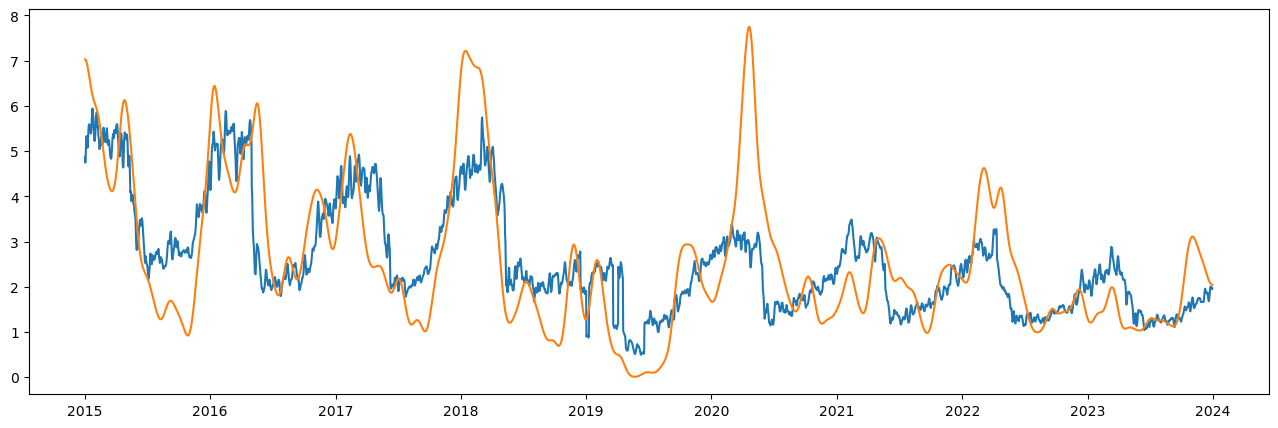

In [52]:
kernel_density_estimate = us.kernel_intensity_estimate_reflect(X_observed, 14, domain= (0, T))
tt = np.arange(0, T, 1)
tt = pd.date_range(start=timestamps[timestamps.year.isin(years)][0], periods=T, freq="D")

plt.figure(figsize=(16,5))
plt.plot(tt, hawkes_intensity, label = "Hawkes")
plt.plot(tt, kernel_density_estimate, label = "kde")
#plt.plot(tt, X_hawkes[:, 0])
plt.show()

/var/folders/2x/b0cqdl5d0vjf5j8bm2f1y6t00000gn/T/ipykernel_42970/270293680.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(tt, kernel_density_estimate, 'r-', label='KDE', linestyle = "--")


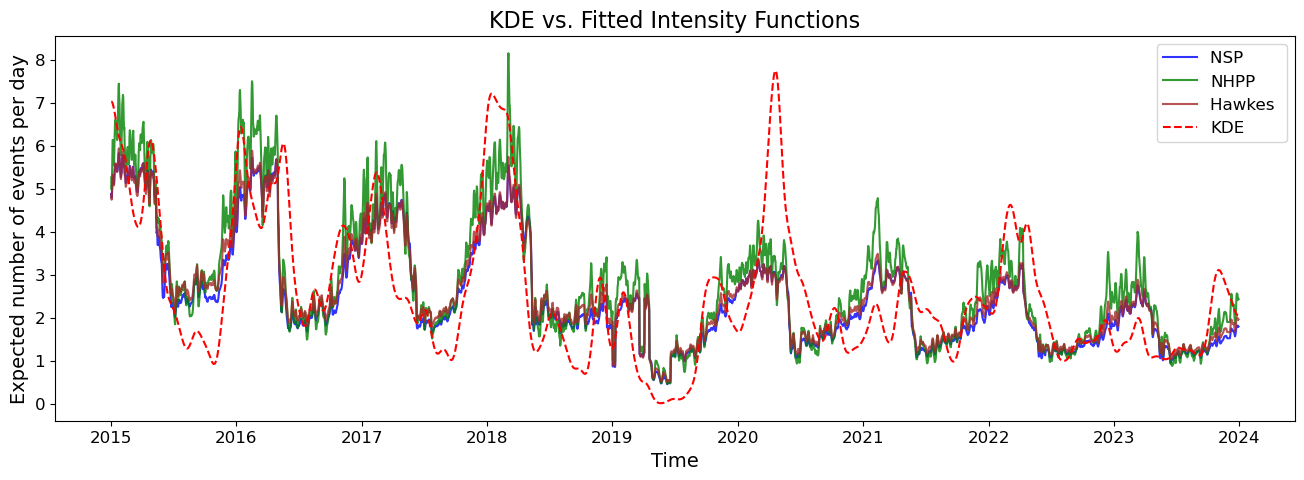

In [93]:
importlib.reload(us)

#year_str = str(year_observed)
X_cov = us.covariate_formater(df_metro, years, x_p = p - 3, T = T)

lambda_fitted = np.array([us.lambda_intensity(t, X_cov, MLE_observed[2:], error = 0) for t in range(T)]) * np.exp(MLE_observed[0])

kernel_density_estimate = us.kernel_intensity_estimate_reflect(X_observed, 14, domain= (0, T))

lam_fit = intensity(res.x, df_design[df_design.index.year.isin(years)].drop(columns="time").values)

tt = np.arange(0, T, 1)
tt = pd.date_range(start=timestamps[timestamps.year.isin(years)][0], periods=T, freq="D")
fig, ax1 = plt.subplots(figsize=(16, 5))  # width=16, height=5

ax1.plot(tt, lambda_fitted, 'b-', label='NSP ', alpha = 0.8)
ax1.plot(tt, lam_fit[:T], 'g-', label='NHPP', alpha = 0.8)
ax1.plot(tt, hawkes_intensity, 'brown', label='Hawkes ', alpha = 0.8)
ax1.set_ylabel('λ_fitted')
ax1.tick_params(axis='y')
"""
ax2 = ax1.twinx()
ax2.plot(tt, X_cov[0, :], 'purple', label='wp')
ax2.plot(tt, X_cov[1, :], 'pink', label='temp')
ax2.plot(tt, X_cov[2, :], 'yellow', label='N_geo')
ax2.set_ylabel('Cov value')
ax2.tick_params(axis='y')
"""
ax1.plot(tt, kernel_density_estimate, 'r-', label='KDE', linestyle = "--")
ax1.set_ylabel('Expected number of events per day')
plt.legend()
plt.xlabel('Time')
plt.title(f'KDE vs. Fitted Intensity Functions')
plt.show()


In [134]:
#Observed data save:

np.savez("observed_and_training.npz", 
         SS_train_pre=X_global_train_pre, 
         params_train_pre=params_train_pre, 
         SS_mean=SS_mean, 
         SS_std=SS_std,
         params_mean = params_mean,
         params_std = params_std,
         SS_observed_normalized = SS_observed_normalized)

# K-function for Hawkes

In [66]:
import numpy as np

def simulate_hawkes(T, beta, alpha, delta, X, dt=1.0, seed=None):
    """
    Simulate a Hawkes process with exponential kernel and piecewise-constant covariates.
    
    Args:
        T : float
            Total simulation time (days)
        beta : array, shape (p+1,)
            Regression coefficients, first element is intercept
        alpha : float
            Hawkes kernel magnitude
        delta : float
            Hawkes kernel decay
        X : array, shape (n_days, p)
            Covariates, daily values
        dt : float
            Time step for piecewise-constant covariates (default 1 day)
        seed : int or None
            Random seed
    
    Returns:
        events : list of floats
            Event times
    """
    if seed is not None:
        np.random.seed(seed)
        
    events = []
    t = 0.0
    h = 0.0  # cumulative excitation
    n_days, p = X.shape
    
    while t < T:
        day_idx = int(t // dt)
        day_idx = min(day_idx, n_days - 1)
        
        # background intensity for current day
        mu_t = np.exp(beta[0] + X[day_idx] @ beta[1:])
        # current intensity including excitation
        lam_t = mu_t + alpha * h
        
        # upper bound for thinning
        lam_max = lam_t
        
        # propose next event
        u = np.random.uniform()
        w = -np.log(u) / lam_max  # exponential inter-event time
        t_next = t + w
        
        # update decay of excitation
        h = h * np.exp(-delta * w)
        
        # intensity at proposed time
        day_idx_next = int(t_next // dt)
        day_idx_next = min(day_idx_next, n_days - 1)
        mu_next = np.exp(beta[0] + X[day_idx_next] @ beta[1:])
        lam_next = mu_next + alpha * h
        
        # accept/reject
        if np.random.uniform() < lam_next / lam_max:
            events.append(t_next)
            h += 1  # add contribution of new event
        
        t = t_next
        
    return np.array(events)

In [82]:
T_H = X_hawkes.shape[0]  # total days
beta = res_hawkes.x[:X_hawkes.shape[1]+1]  # intercept + covariates
alpha, delta = res_hawkes.x[-2:]

Hawkes_MLE_sim = [ simulate_hawkes(T_H, beta, alpha, delta, X_hawkes) for i in range(1000)]


In [83]:
K_hawkes = np.array([us.ripley_K_1D_SS_test(Hawkes_MLE_sim[i], r_K, T_H) for i in range(len(Hawkes_MLE_sim))])


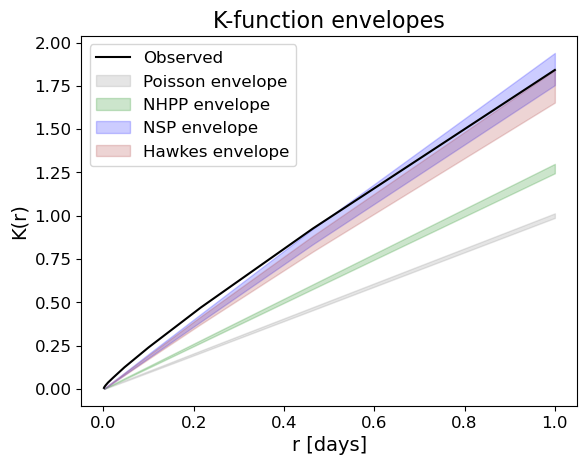

In [92]:


# Compute envelopes
lower_P = np.percentile(R_K_P, 2.5, axis=0)
upper_P = np.percentile(R_K_P, 97.5, axis=0)

lower_NHPP = np.percentile(R_K_NHPP, 2.5, axis=0)
upper_NHPP = np.percentile(R_K_NHPP, 97.5, axis=0)

lower_NS = np.percentile(R_K_NS, 2.5, axis=0)
upper_NS = np.percentile(R_K_NS, 97.5, axis=0)

lower_H = np.percentile(K_hawkes, 2.5, axis=0)
upper_H = np.percentile(K_hawkes, 97.5, axis=0)

plt.figure()
plt.plot(r_K, R_K_observed, 'k-', label="Observed")


# Envelope for Poisson simulations
plt.fill_between(r_K, lower_P, upper_P, color="grey", alpha=0.2, label="Poisson envelope")

# Envelope for NHPP simulations
plt.fill_between(r_K, lower_NHPP, upper_NHPP, color="green", alpha=0.2, label="NHPP envelope")

# Envelope for Neyman–Scott simulations
plt.fill_between(r_K, lower_NS, upper_NS, color="blue", alpha=0.2, label="NSP envelope")

plt.fill_between(r_K, lower_H, upper_H, color="brown", alpha=0.2, label="Hawkes envelope")


plt.legend()
plt.xlabel("r [days]")
plt.ylabel("K(r)")
plt.title("K-function envelopes")
plt.show()

# Including NLE fit of NSP

In [37]:
NLE_observed_norm = np.array([ 1.5141569 ,  1.7302576 , -0.9411681 ,  0.04086089, -0.1346153 , 0.43642712])
params_std = np.array([1.99409629, 1.99409741, 1.44337478, 0.86602511, 0.86602626,
       1.15470093])
params_mean = np.array([-1.15128748, -3.45387693, -0.4999981 , -0.49999926, -0.50000081,
        0.99999908])

years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

In [38]:
importlib.reload(us)
p = 6
params_NLE = np.append((NLE_observed_norm*params_std) + params_mean, 0)
#N_boot = 100
#X_NLE_sim, Y_NLE_sim, _, _ = us.simulate_given_params(1,1,365*len(years), p, df_metro, np.repeat(params_NLE.reshape((1, -1)), N_boot, axis = 0))
T = 365*len(years)
X_cov = us.covariate_formater(df_metro, years, x_p = p - 3, T = T)

lambda_fitted_NLE = np.array([us.lambda_intensity(t, X_cov, params_NLE[2:-1], error = 0) for t in range(T)]) * np.exp(params_NLE[0])


/var/folders/2x/b0cqdl5d0vjf5j8bm2f1y6t00000gn/T/ipykernel_11818/2671353818.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(tt, kernel_density_estimate, 'r-', label='KDE', linestyle = "--")


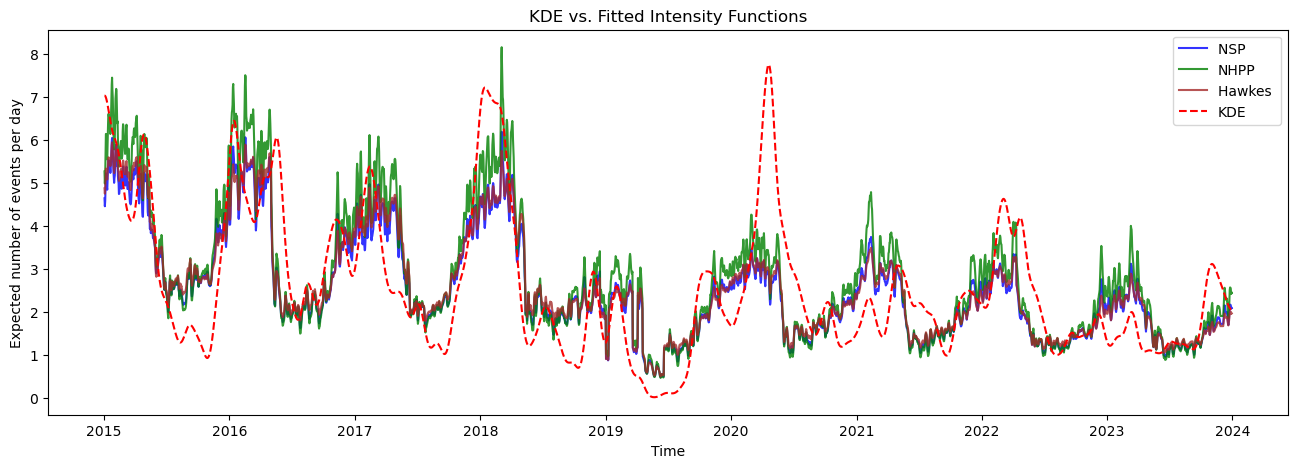

In [53]:
importlib.reload(us)

#year_str = str(year_observed)
X_cov = us.covariate_formater(df_metro, years, x_p = p - 3, T = T)

kernel_density_estimate = us.kernel_intensity_estimate_reflect(X_observed, 14, domain= (0, T))

lam_fit = intensity(res.x, df_design[df_design.index.year.isin(years)].drop(columns="time").values)

tt = np.arange(0, T, 1)
tt = pd.date_range(start=timestamps[timestamps.year.isin(years)][0], periods=T, freq="D")
fig, ax1 = plt.subplots(figsize=(16, 5))  # width=16, height=5

ax1.plot(tt, lambda_fitted_NLE, 'b-', label='NSP ', alpha = 0.8)

ax1.plot(tt, lam_fit[:T], 'g-', label='NHPP', alpha = 0.8)
ax1.plot(tt, hawkes_intensity, 'brown', label='Hawkes ', alpha = 0.8)
ax1.set_ylabel('λ_fitted')
ax1.tick_params(axis='y')
"""
ax2 = ax1.twinx()
ax2.plot(tt, X_cov[0, :], 'purple', label='wp')
ax2.plot(tt, X_cov[1, :], 'pink', label='temp')
ax2.plot(tt, X_cov[2, :], 'yellow', label='N_geo')
ax2.set_ylabel('Cov value')
ax2.tick_params(axis='y')
"""
ax1.plot(tt, kernel_density_estimate, 'r-', label='KDE', linestyle = "--")
ax1.set_ylabel('Expected number of events per day')
plt.legend()
plt.xlabel('Time')
plt.title(f'KDE vs. Fitted Intensity Functions')
plt.show()
